In [1]:
import pandas as pd
import numpy as np
import joblib
import os

# 1. Load processed train and test datasets
train_df = pd.read_csv('../data/processed/train_processed.csv')
test_df = pd.read_csv('../data/processed/test_processed.csv')

print("Train Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)

# 2. Load the best model from Day 4 using joblib
model_path = '../models/best_model.pkl'
best_model = joblib.load(model_path)

print("\nBest Model successfully loaded via joblib!")
print(best_model)

Train Dataset Shape: (712, 8)
Test Dataset Shape: (179, 8)

Best Model successfully loaded via joblib!
RandomForestClassifier(random_state=42)


True Negatives (TN): 94
False Positives (FP): 16
False Negatives (FN): 21
True Positives (TP): 48


<Figure size 600x600 with 0 Axes>

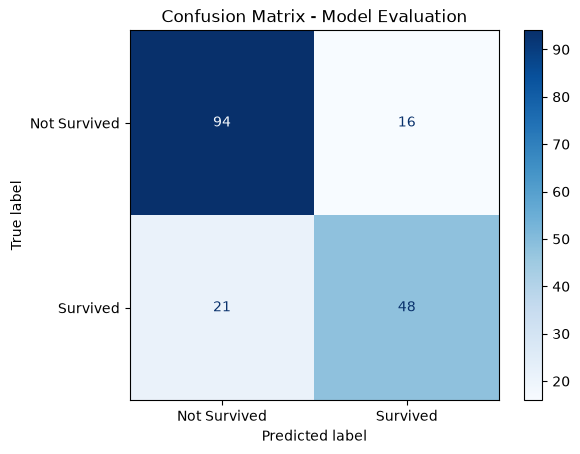

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os

# 1. Prepare Train and Test data
X_train = train_df.drop(columns=['Survived'])
y_train = train_df['Survived']

X_test = test_df.drop(columns=['Survived'])
y_test = test_df['Survived']

# Handle categorical columns and align features
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 2. Train the model and make predictions
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 3. Create outputs/figures directory if it doesn't exist
os.makedirs('../outputs/figures', exist_ok=True)

# 4. Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# 5. Plot Confusion Matrix
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix - Model Evaluation')

# 6. Save plot as PNG deliverable
plt.savefig('../outputs/figures/confusion_matrix.png', bbox_inches='tight')
plt.show()

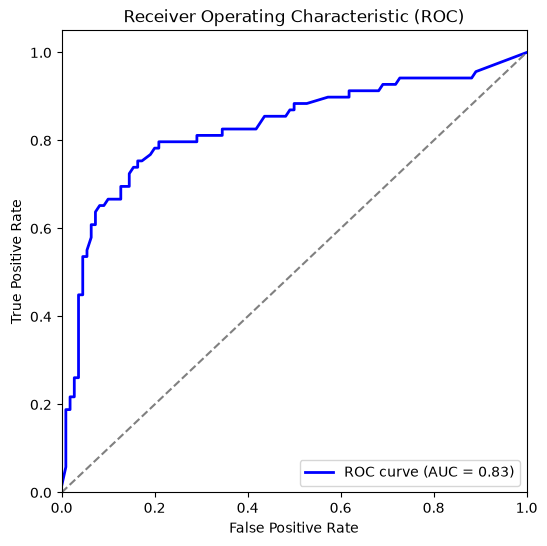

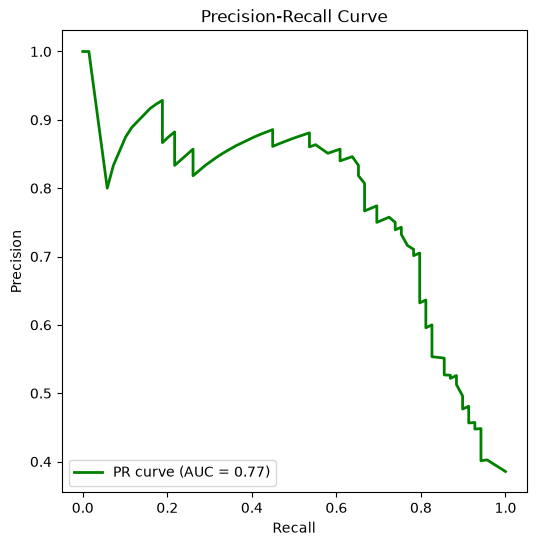

ROC-AUC Score: 0.8290
PR-AUC Score: 0.7738


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 1. Ensure data and model are ready in this cell
X_train = train_df.drop(columns=['Survived'])
y_train = train_df['Survived']
X_test = test_df.drop(columns=['Survived'])
y_test = test_df['Survived']

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# 2. Generate probabilities for the positive class
y_prob = clf.predict_proba(X_test)[:, 1]

# 3. Calculate and plot ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig('../outputs/figures/roc_curve.png', bbox_inches='tight')
plt.show()

# 4. Calculate and plot Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.savefig('../outputs/figures/precision_recall_curve.png', bbox_inches='tight')
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score: {pr_auc:.4f}")

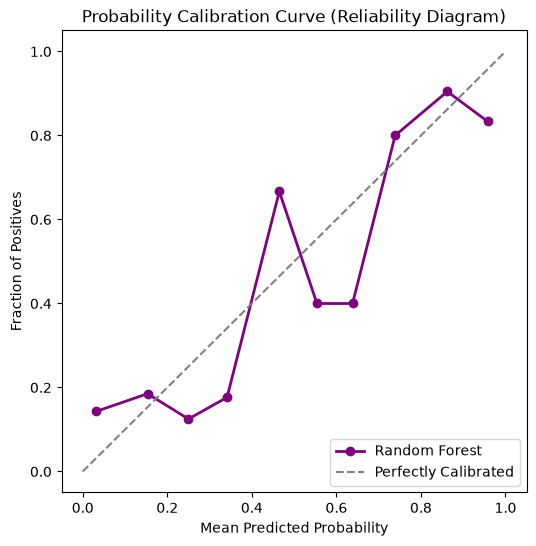

In [4]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# 1. Calculate calibration curve values
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')

# 2. Plot Calibration Curve
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, color='purple', label='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Probability Calibration Curve (Reliability Diagram)')
plt.legend(loc='lower right')
plt.savefig('../outputs/figures/calibration_curve.png', bbox_inches='tight')
plt.show()

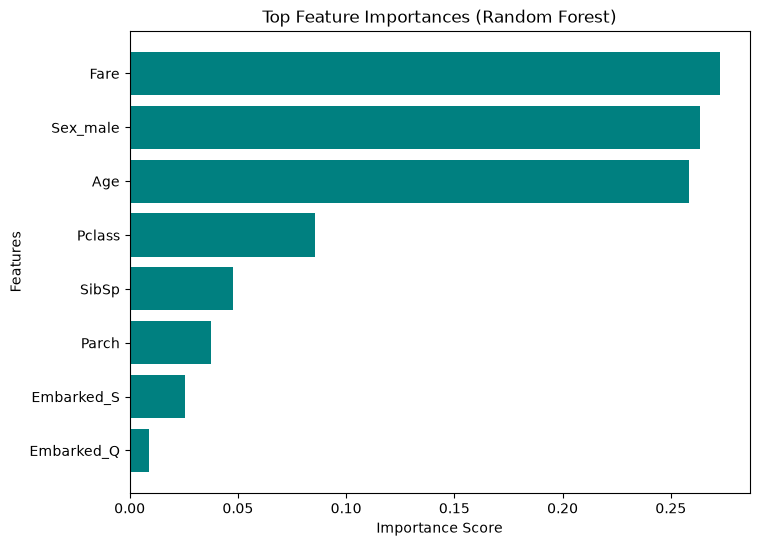

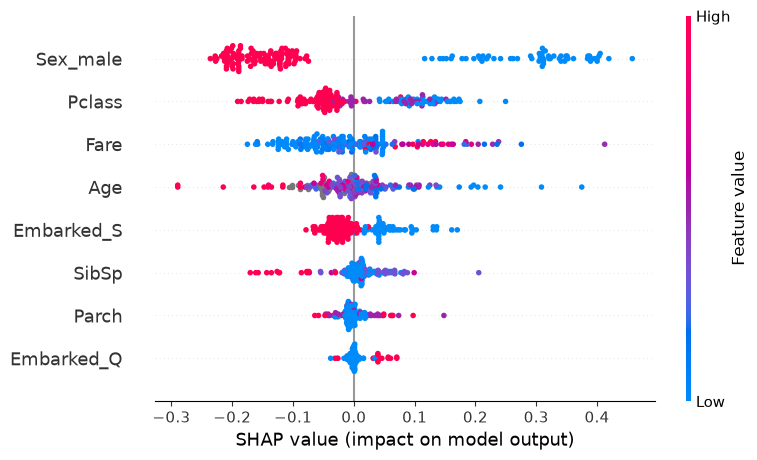

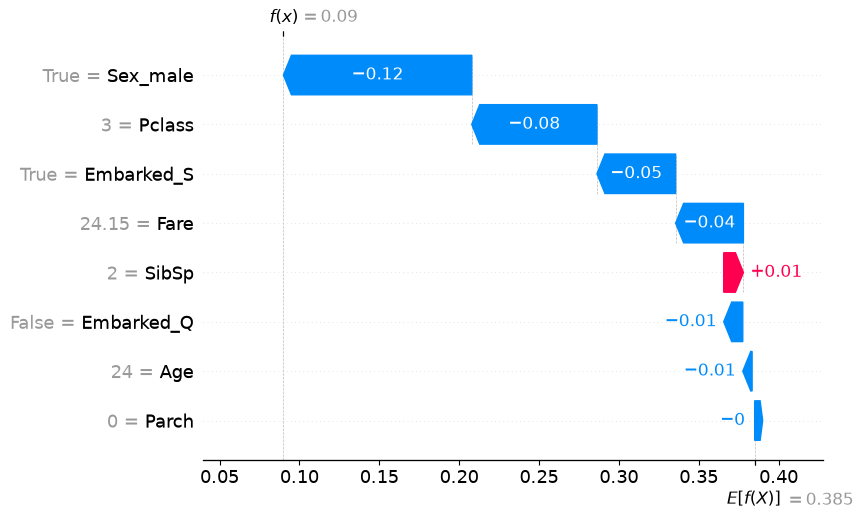

All Feature Importance and SHAP plots generated and saved successfully!


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import shap

# 1. Feature Importance Plot (Random Forest Built-in)
importances = clf.feature_importances_
feature_names = X_test.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(feature_imp_df['Feature'][:10], feature_imp_df['Importance'][:10], color='teal')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.savefig('../outputs/figures/feature_importance.png', bbox_inches='tight')
plt.show()

# 2. SHAP Summary and Waterfall Plots (Updated for multi-output shape)
explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_test)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
plt.savefig('../outputs/figures/shap_summary.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[0, :, 1], show=False)
plt.savefig('../outputs/figures/shap_waterfall.png', bbox_inches='tight')
plt.show()

print("All Feature Importance and SHAP plots generated and saved successfully!")

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Thresholds to evaluate
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
evaluation_results = []

for th in thresholds:
    # Convert probabilities to binary predictions based on current threshold
    y_pred_th = (y_prob >= th).astype(int)
    
    prec = precision_score(y_test, y_pred_th, zero_division=0)
    rec = recall_score(y_test, y_pred_th, zero_division=0)
    f1 = f1_score(y_test, y_pred_th, zero_division=0)
    
    evaluation_results.append({
        'Threshold': th,
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

# Create and display evaluation table
threshold_df = pd.DataFrame(evaluation_results)
print("Threshold Tuning Results:")
print(threshold_df)

Threshold Tuning Results:
   Threshold  Precision  Recall  F1-Score
0        0.3     0.6364  0.8116    0.7134
1        0.4     0.7324  0.7536    0.7429
2        0.5     0.7500  0.6957    0.7218
3        0.6     0.7667  0.6667    0.7132
4        0.7     0.8571  0.6087    0.7119


In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# 1. Standard prediction using default threshold 0.50
y_pred_default = (y_prob >= 0.50).astype(int)
cm = confusion_matrix(y_test, y_pred_default)
tn, fp, fn, tp = cm.ravel()

# 2. Define business costs for errors
cost_fp = 50   # Cost per False Positive
cost_fn = 200  # Cost per False Negative

# 3. Calculate total business cost
total_cost = (fp * cost_fp) + (fn * cost_fn)

print(f"False Positives (FP): {fp} | Cost: ${fp * cost_fp}")
print(f"False Negatives (FN): {fn} | Cost: ${fn * cost_fn}")
print(f"Total Business Error Cost: ${total_cost}")

False Positives (FP): 16 | Cost: $800
False Negatives (FN): 21 | Cost: $4200
Total Business Error Cost: $5000


In [8]:
import pandas as pd

# 1. Create a DataFrame to analyze incorrect predictions
analysis_df = X_test.copy()
analysis_df['Actual'] = y_test.values
analysis_df['Predicted'] = y_pred_default
analysis_df['Probability'] = y_prob

# 2. Filter out only the incorrectly classified rows
errors_df = analysis_df[analysis_df['Actual'] != analysis_df['Predicted']]

print(f"Total Incorrect Predictions: {len(errors_df)}")
print("\nSample of Incorrect Predictions:")
print(errors_df[['Actual', 'Predicted', 'Probability']].head(10))

Total Incorrect Predictions: 37

Sample of Incorrect Predictions:
    Actual  Predicted  Probability
2        1          0     0.050000
5        1          0     0.260000
7        0          1     0.830000
8        0          1     0.530000
27       1          0     0.190000
28       1          0     0.160000
34       1          0     0.390000
36       1          0     0.300000
41       0          1     0.690000
52       0          1     0.894066
